# HyperscaleES: Fine-tune RWKV7 0.1B with Evolutionary Strategies

This notebook fine-tunes the smallest available RWKV7 model (100M params) using the EggRoll evolutionary strategy.

**Requirements:** Colab with T4 GPU runtime.

In [5]:
# Verify GPU is available
!nvidia-smi

Sun Feb 15 16:20:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P8             15W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
!git clone -b warming-up https://github.com/shr1ram/HyperscaleES.git
%cd HyperscaleES
!pip install -e . -q

fatal: destination path 'HyperscaleES' already exists and is not an empty directory.
/content/HyperscaleES/HyperscaleES
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for hyperscalees (pyproject.toml) ... done


## 2. Run the end-to-end test

Quick sanity check: trains a small MLP to predict the number 2.

In [7]:
!python tests/end_to_end_test.py

2026-02-15 16:21:05.682216: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771172465.702451    8885 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771172465.709017    8885 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771172465.724528    8885 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771172465.724554    8885 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771172465.724557    8885 computation_placer.cc:177] computation placer alr

## 3. Fine-tune RWKV7 0.1B

This downloads the 0.1B model (~380MB) and fine-tunes it using evolutionary strategies.

Key parameters you can adjust:
- `--model_choice`: Model size (`7g0.1B`, `7g0.4B`, `7g1.5B`, etc.)
- `--task`: Training task (default `fastzero`)
- `--num_epochs`: Number of evolution epochs (default 100)
- `--parallel_generations_per_gpu`: Population size per device (default 1024, reduce if OOM)
- `--lr_scale`: Learning rate (default 1.0)
- `--sigma`: Noise magnitude (default 1e-3)
- `--temperature`: Sampling temperature (default 0.0 = greedy)
- `--track`: Enable wandb logging

In [8]:
# Fine-tune with default settings (output saved to train.log for plotting)
!python -m llm_experiments.general_do_evolution \
    --model_choice 7g0.1B \
    --task fastzero \
    --num_epochs 50 \
    --parallel_generations_per_gpu 1024 \
    --sigma 1e-3 \
    --lr_scale 1.0 2>&1 | tee train.log

2026-02-15 16:21:24.798375: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771172484.818852    8992 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771172484.825525    8992 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771172484.841392    8992 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771172484.841414    8992 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771172484.841417    8992 computation_placer.cc:177] computation placer alr

## 4. (Optional) Reduce batch size if you hit OOM

If the above cell runs out of GPU memory, try reducing `parallel_generations_per_gpu`:

In [9]:
# Smaller batch size if OOM
# !python -m llm_experiments.general_do_evolution \
#     --model_choice 7g0.1B \
#     --task fastzero \
#     --num_epochs 50 \
#     --parallel_generations_per_gpu 256 \
#     --sigma 1e-3 \
#     --lr_scale 1.0

## 5. Training plots

In [10]:
import re
import matplotlib.pyplot as plt

# Try train.log first, fall back to parsing cell output above
try:
    with open("train.log") as f:
        log = f.read()
    print("Reading from train.log")
except FileNotFoundError:
    # If no log file, grab output from the training cell
    # Copy-paste the training cell output into train.log first:
    print("No train.log found. Run this in a cell first:")
    print('  %%writefile train.log')
    print('  <paste training output here>')
    raise SystemExit

epochs, avg_fit, std_fit, max_fit, min_fit, median_fit = [], [], [], [], [], []
lora_upd, nonlora_upd = [], []
val_epochs, val_scores = [], []
epoch_times = []

# Extract per-epoch stats
for m in re.finditer(r"\tavg_fitness:\s*([-\d.e+]+).*?\tstd_fitness:\s*([-\d.e+]+).*?\tmax_fitness:\s*([-\d.e+]+).*?\tmin_fitness:\s*([-\d.e+]+).*?\tmedian_fitness:\s*([-\d.e+]+).*?\tlora_updates:\s*([-\d.e+]+).*?\tnonlora_updates:\s*([-\d.e+]+).*?\ttoken_gen_time:\s*([-\d.e+]+)", log, re.DOTALL):
    avg_fit.append(float(m.group(1)))
    std_fit.append(float(m.group(2)))
    max_fit.append(float(m.group(3)))
    min_fit.append(float(m.group(4)))
    median_fit.append(float(m.group(5)))
    lora_upd.append(float(m.group(6)))
    nonlora_upd.append(float(m.group(7)))
    epoch_times.append(float(m.group(8)))

epochs = list(range(len(avg_fit)))

# Extract validation scores
for m in re.finditer(r"VALIDATION SCORE=\s*([-\d.e+]+)", log):
    val_scores.append(float(m.group(1)))
val_epochs = [i * 10 for i in range(len(val_scores))]

print(f"Parsed {len(epochs)} training epochs, {len(val_scores)} validation points")

Reading from train.log
Parsed 50 training epochs, 5 validation points


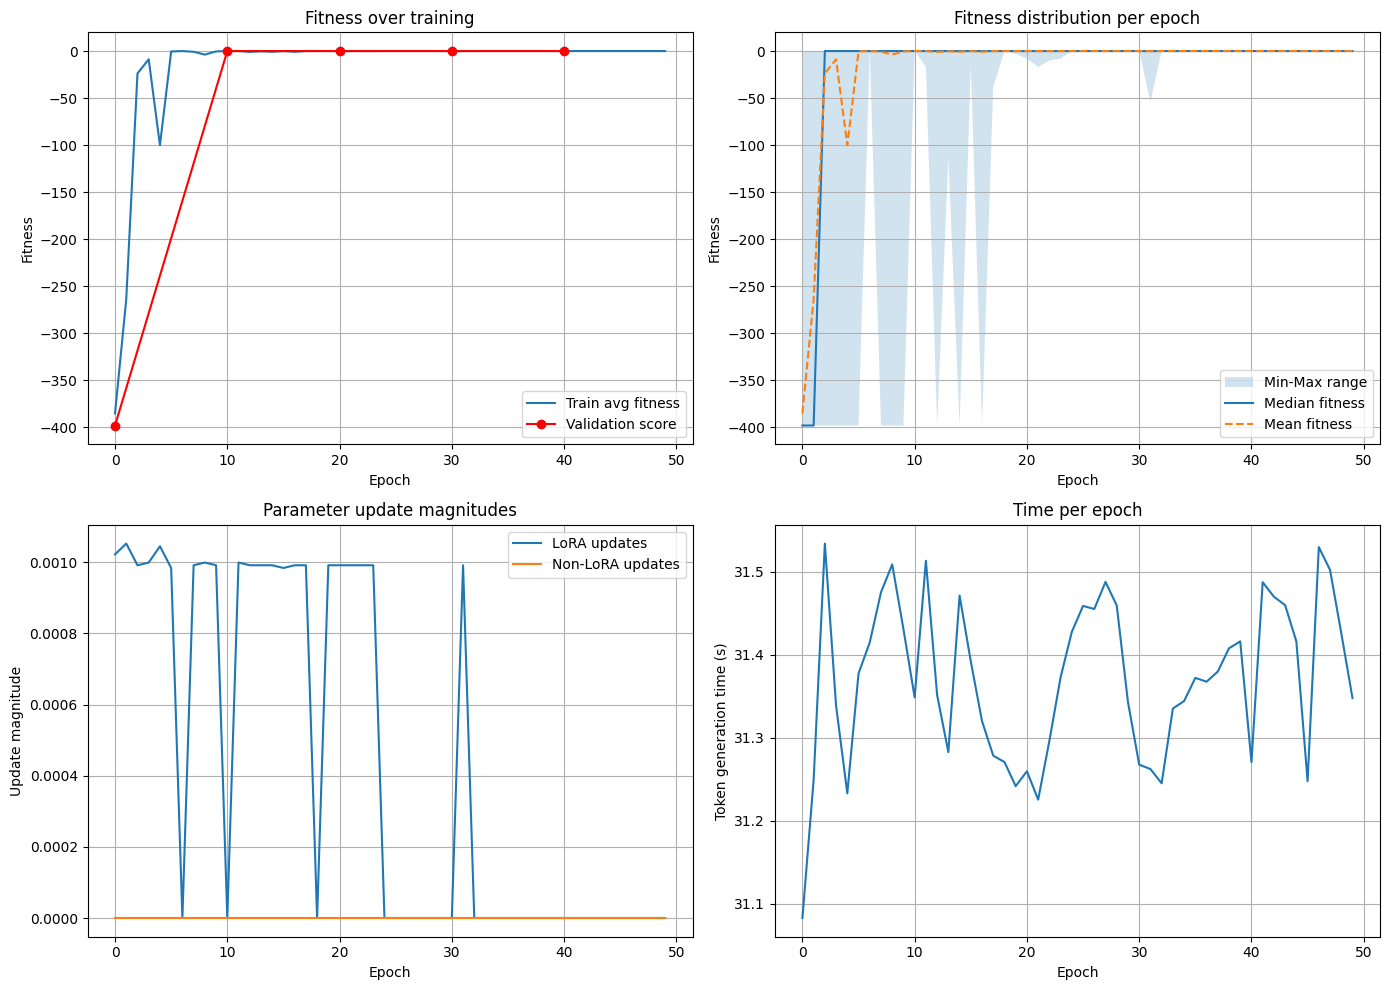

Saved to training_plots.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Average fitness over epochs
ax = axes[0, 0]
ax.plot(epochs, avg_fit, label="Train avg fitness")
if val_scores:
    ax.plot(val_epochs, val_scores, 'ro-', label="Validation score")
ax.set_xlabel("Epoch")
ax.set_ylabel("Fitness")
ax.set_title("Fitness over training")
ax.legend()
ax.grid(True)

# 2. Fitness spread (min/max/median)
ax = axes[0, 1]
ax.fill_between(epochs, min_fit, max_fit, alpha=0.2, label="Min-Max range")
ax.plot(epochs, median_fit, label="Median fitness")
ax.plot(epochs, avg_fit, label="Mean fitness", linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Fitness")
ax.set_title("Fitness distribution per epoch")
ax.legend()
ax.grid(True)

# 3. LoRA vs non-LoRA update magnitudes
ax = axes[1, 0]
ax.plot(epochs, lora_upd, label="LoRA updates")
ax.plot(epochs, nonlora_upd, label="Non-LoRA updates")
ax.set_xlabel("Epoch")
ax.set_ylabel("Update magnitude")
ax.set_title("Parameter update magnitudes")
ax.legend()
ax.grid(True)

# 4. Time per epoch
ax = axes[1, 1]
ax.plot(epochs, epoch_times)
ax.set_xlabel("Epoch")
ax.set_ylabel("Token generation time (s)")
ax.set_title("Time per epoch")
ax.grid(True)

plt.tight_layout()
plt.savefig("training_plots.png", dpi=150)
plt.show()
print("Saved to training_plots.png")